In [1]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn pyarrow -q

import os
import platform
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# 결과 저장용 임시 폴더 (이 노트북 옆에 'd009_outputs/' 가 만들어집니다)
OUT_DIR = Path("d009_outputs")
OUT_DIR.mkdir(exist_ok=True)

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("저장 폴더:", OUT_DIR.resolve())

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3
저장 폴더: C:\Users\baram\my-first\ai-data-bootcamp\D009\d009_outputs


In [2]:
# 종합 프로젝트용 새 데이터 생성 — 베이커리 체인 "빵셀러" 운영 데이터
np.random.seed(13)
n_days = 90
n_stores = 6
n_rows = n_days * n_stores * 4   # 매장 x 일자 x 시간대(4구간)

stores = [f"S{i:02d}" for i in range(1, n_stores + 1)]
items = ["크루아상", "식빵", "케이크", "샌드위치", "쿠키"]

bakery = pd.DataFrame({
    "store_id": np.tile(stores, n_rows // n_stores)[:n_rows],
    "date_str": np.random.choice([
        "2025-04-01", "2025/04/01", "20250401",
        "2025-05-15", "2025/05/15", "20250515",
        "2025-06-20", "2025/06/20", "20250620",
    ], n_rows),
    "item": np.random.choice(items, n_rows),
    "quantity": np.random.choice([1, 1, 2, 2, 3, 5, 50], n_rows),  # 50은 의심값
    "unit_price": np.random.choice([3500, 4500, 5500, 8500, 12000], n_rows),
})
bakery["revenue"] = bakery["quantity"] * bakery["unit_price"]

# 오염 심기
bakery.loc[np.random.choice(n_rows, 60, replace=False), "revenue"] = np.nan
bakery.loc[5, "revenue"] = -45000  # 환불 또는 실수
bakery.loc[bakery.sample(10, random_state=1).index, "store_id"] = " S01 "  # 공백
bakery.loc[bakery.sample(8, random_state=2).index, "item"] = "케익"        # 표기 혼재('케이크' vs '케익')
bakery = pd.concat([bakery, bakery.iloc[[0, 1, 2, 3]]], ignore_index=True)   # 중복 4건

print("빵셀러 데이터 생성 완료:", bakery.shape)
bakery.head()

빵셀러 데이터 생성 완료: (2164, 6)


,store_id,date_str,item,quantity,unit_price,revenue
0,S01,20250401,쿠키,2,12000,24000.0
1,S02,2025-04-01,케이크,2,12000,24000.0
2,S03,2025-04-01,쿠키,1,5500,5500.0
3,S04,2025-06-20,쿠키,2,8500,17000.0
4,S05,20250401,샌드위치,5,4500,22500.0


In [30]:
# ===== 1. 데이터 개요 확인용 코드 =====

print("===== 데이터 개요 =====")
print(f"전체 행 수: {bakery_clean.shape[0]}")
print(f"전체 열 수: {bakery_clean.shape[1]}")
print(f"\n컬럼 목록: {list(bakery_clean.columns)}")
print(f"\n각 컬럼 dtype:")
print(bakery_clean.dtypes)

print(f"\nstore_id 종류: {sorted(bakery_clean['store_id'].unique())}")
print(f"item 종류: {sorted(bakery_clean['item'].unique())}")
print(f"날짜 범위: {bakery_clean['date'].min()} ~ {bakery_clean['date'].max()}")

===== 데이터 개요 =====
전체 행 수: 1784
전체 열 수: 8

컬럼 목록: ['store_id', 'date_str', 'item', 'quantity', 'unit_price', 'revenue', 'date', 'month']

각 컬럼 dtype:
store_id                 str
date_str                 str
item                     str
quantity               int64
unit_price             int64
revenue              float64
date          datetime64[us]
month                    str
dtype: object

store_id 종류: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06']
item 종류: ['샌드위치', '식빵', '케이크', '쿠키', '크루아상']
날짜 범위: 2025-04-01 00:00:00 ~ 2025-06-20 00:00:00


In [4]:
# 예제: 품질 리포트 함수 v2 — 수치형 컬럼에 IQR 이상치 비율을 추가
def quality_report_full(df: pd.DataFrame, name: str = "df") -> pd.DataFrame:
    '''v1에 수치형 이상치 비율(IQR)과 의심 타입 컬럼 표시를 추가합니다.'''
    n_rows = len(df)
    base = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    })

    # IQR 이상치 비율 (수치형 컬럼만)
    outlier_pct = {}
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_pct[col] = ((s < lo) | (s > hi)).mean() * 100
    base["outlier_pct_iqr"] = pd.Series(outlier_pct).round(2)

    # object 컬럼이 실제로는 날짜로 파싱되는지 의심 표시
    suspicious_datetime = []
    for col in df.select_dtypes(include="object").columns:
        try:
            parsed = pd.to_datetime(df[col], errors="coerce")
            if parsed.notna().mean() > 0.8:
                suspicious_datetime.append(col)
        except Exception:
            pass
    base["maybe_datetime"] = base.index.isin(suspicious_datetime)

    print(f"[품질 리포트(완전판)] {name}")
    print(f"  행 수: {n_rows:,}  /  열 수: {len(df.columns)}")
    print(f"  완전 중복 행: {df.duplicated().sum()}건")
    if suspicious_datetime:
        print(f"  📌 날짜로 보이는 object 컬럼: {suspicious_datetime}")
    return base



In [5]:
qr_bakery = quality_report_full(bakery, "bakery")
qr_bakery

[품질 리포트(완전판)] bakery
  행 수: 2,164  /  열 수: 6
  완전 중복 행: 321건


,dtype,missing,missing_pct,n_unique,outlier_pct_iqr,maybe_datetime
store_id,str,0,0.00,7,NaN,False
date_str,str,0,0.00,9,NaN,False
item,str,0,0.00,6,NaN,False
quantity,int64,0,0.00,5,14.56,False
unit_price,int64,0,0.00,5,0.00,False
revenue,float64,60,2.77,26,17.30,False


In [ ]:
# 시나리오 1 — 모범 답안
# qr_bakery = quality_report_full(bakery, "bakery")
# qr_bakery

- 결측률이 가장 높은 칼럼 : revenue (2.77%) (실제 결측 (60건) 존재)

- maybe_datetime = True 로 잡힌 칼럼 : 없음 (date_str 컬럼은 문자열(str) 형식이며, 결측치 또는 형식 오류로 인해 날짜 파싱 성공률이 기준(80%) 미달 — 데이터 정제 후 파싱 필요)

- 수치형 중 IQR 이상치 비율이 가장 높은 칼럼 : revenue (17.30%) (revenue = quantity*unit_price , quantity의 이상치에 영향을 받는다) -> 이상치 처리 후 결측치 처리 필요 , 그 다음 quantity (14.56%) (값 50이 이상치로 반영)


In [33]:
# ===== 방법 1: 개수와 비율 =====
n_50 = (bakery_clean["quantity"] == 50).sum()
total = len(bakery_clean)

print(f"quantity=50 발생 건수: {n_50}건")
print(f"전체 대비 비율: {n_50/total:.1%}")

# ===== 방법 2: 전체 분포 한눈에 보기 =====
print("\nquantity 값별 분포:")
print(bakery_clean["quantity"].value_counts().sort_index())
print("\n비율(%):")
print(bakery_clean["quantity"].value_counts(normalize=True).sort_index() * 100)

quantity=50 발생 건수: 277건
전체 대비 비율: 15.5%

quantity 값별 분포:
quantity
1     488
2     483
3     295
5     241
50    277
Name: count, dtype: int64

비율(%):
quantity
1     27.354260
2     27.073991
3     16.535874
5     13.508969
50    15.526906
Name: proportion, dtype: float64


quantity = 50은 다른 수량과 비슷한 비율로 발생, 이상치로 정제하지 않고 정상범위로 간주하는 게 좋을 듯

In [9]:
def drop_full_duplicates(df):
    """1. 완전 중복 행 제거"""
    return df.drop_duplicates()
def strip_store_id(df):
    """2. store_id 앞뒤 공백 제거"""
    df = df.copy()
    df["store_id"] = df["store_id"].str.strip()
    return df
def unify_item_name(df):
    """3. item '케익' -> '케이크' 통일"""
    df = df.copy()
    df["item"] = df["item"].replace({"케익": "케이크"})
    return df
def parse_date(df):
    """4. date_str을 date 컬럼(datetime)으로 파싱"""
    df = df.copy()
    df["date"] = pd.to_datetime(df["date_str"], errors="coerce", format="mixed")
    return df
def split_refunds(df):
    """5. revenue < 0인 행은 refunds_bakery로 분리"""
    global refunds_bakery
    mask = df["revenue"] < 0
    refunds_bakery = df.loc[mask].copy()
    return df.loc[~mask].copy()
def drop_missing_revenue(df):
    """6. revenue 결측 행 제거"""
    df = df.copy()
    return df.dropna(subset=["revenue"])

bakery_clean = (
    bakery
    .pipe(drop_full_duplicates)
    .pipe(strip_store_id)
    .pipe(unify_item_name)
    .pipe(parse_date)
    .pipe(split_refunds)
    .pipe(drop_missing_revenue)
)

print("bakery_clean:", bakery_clean.shape)
print("refunds_bakery:", refunds_bakery.shape)
bakery_clean.head()



bakery_clean: (1784, 7)
refunds_bakery: (1, 7)


,store_id,date_str,item,quantity,unit_price,revenue,date
0,S01,20250401,쿠키,2,12000,24000.0,2025-04-01
1,S02,2025-04-01,케이크,2,12000,24000.0,2025-04-01
2,S03,2025-04-01,쿠키,1,5500,5500.0,2025-04-01
3,S04,2025-06-20,쿠키,2,8500,17000.0,2025-06-20
4,S05,20250401,샌드위치,5,4500,22500.0,2025-04-01


In [10]:
print(f"정제 전: {bakery.shape}  →  정제 후: {bakery_clean.shape}")
print(f"환불 보관: {len(refunds_bakery)}건")
print(f"item 종류: {bakery_clean['item'].unique()}")

정제 전: (2164, 6)  →  정제 후: (1784, 7)
환불 보관: 1건
item 종류: <ArrowStringArray>
['쿠키', '케이크', '샌드위치', '크루아상', '식빵']
Length: 5, dtype: str


In [ ]:
# 예제: 결정 로그를 리스트로 누적하다가 마지막에 표로 출력
decisions = []


def log_decision(step: str, action: str, reason: str, result: str):
    decisions.append({"step": step, "action": action, "reason": reason, "result": result})


log_decision(
    "1. 중복 제거",
    "완전 중복 행 drop",
    "동일 키 동일 값은 시스템 입력 오류로 간주",
    "321건 제거",
)
log_decision(
    "2. 문자열 정제",
    "store_id를 'strip' & item '케익' -> '케이크'로 통일",
    "문자열 공백 제거 및 표기 혼재 통일",
    "store_id 공백 (10건), item 케익 (8건) 통일",
)
log_decision(
    "3. 날짜 파싱",
    "date_str을 datetime으로",
    "월별 집계가 분석 목적이므로 datetime 필요",
    f"NaT(파싱 실패): {bakery_clean['date_str'].isna().sum()}건",
)
log_decision(
    "4. 이상치 처리",
    "음수 revenue 분리, 수량 이상치 50은 자주 발생해 정상 범위로 간주",
    "매출 분석이 목적이므로 환불은 별도 보관",
    f"환불 {len(refunds_bakery)}건, 수량 상위 컷오프 {bakery_clean.loc[(bakery_clean['quantity'] < lower) | (bakery_clean['quantity'] > upper), 'quantity'].unique()}",
)
log_decision(
    "5. 결측치 처리",
    "revenue 결측 행 제거",
    "결측은 결제 실패 로그로 추정(MCAR 가정), 매출 왜곡 방지",
    "최종 60건 내외 제거",
)

decision_log = pd.DataFrame(decisions)
decision_log

,step,action,reason,result
0,1. 중복 제거,완전 중복 행 drop,동일 키 동일 값은 시스템 입력 오류로 간주,321건 제거
1,2. 문자열 정제,store_id를 'strip' & item '케익' -> '케이크'로 통일,문자열 공백 제거 및 표기 혼재 통일,"store_id 공백 (10건), item 케익 (8건) 통일"
2,3. 날짜 파싱,date_str을 datetime으로,월별 집계가 분석 목적이므로 datetime 필요,NaT(파싱 실패): 0건
3,4. 이상치 처리,"음수 revenue 분리, 수량 이상치 50은 자주 발생해 정상 범위로 간주",매출 분석이 목적이므로 환불은 별도 보관,"환불 1건, 수량 상위 컷오프 [50]"
4,5. 결측치 처리,revenue 결측 행 제거,"결측은 결제 실패 로그로 추정(MCAR 가정), 매출 왜곡 방지",최종 60건 내외 제거


In [39]:
#결정로그 표 출력
md_table = "| 단계 | 액션 | 근거 | 결과 |\n|---|---|---|---|\n"
for d in decisions:
    md_table += f"| {d['step']} | {d['action']} | {d['reason']} | {d['result']} |\n"

print(md_table)

| 단계 | 액션 | 근거 | 결과 |
|---|---|---|---|
| 1. 중복 제거 | 완전 중복 행 drop | 동일 키 동일 값은 시스템 입력 오류로 간주 | 321건 제거 |
| 2. 문자열 정제 | store_id를 'strip' & item '케익' -> '케이크'로 통일 | 문자열 공백 제거 및 표기 혼재 통일 | store_id 공백 (10건), item 케익 (8건) 통일 |
| 3. 날짜 파싱 | date_str을 datetime으로 | 월별 집계가 분석 목적이므로 datetime 필요 | NaT(파싱 실패): 0건 |
| 4. 이상치 처리 | 음수 revenue 분리, 수량 이상치 50은 자주 발생해 정상 범위로 간주 | 매출 분석이 목적이므로 환불은 별도 보관 | 환불 1건, 수량 상위 컷오프 [50] |
| 5. 결측치 처리 | revenue 결측 행 제거 | 결측은 결제 실패 로그로 추정(MCAR 가정), 매출 왜곡 방지 | 최종 60건 내외 제거 |



In [11]:
# 시나리오 2 — 모범 답안
# def b_dedup(df): return df.drop_duplicates().reset_index(drop=True)
# def b_strip_store(df): return df.assign(store_id=df["store_id"].str.strip())
# def b_unify_item(df): return df.assign(item=df["item"].replace({"케익": "케이크"}))
# def b_parse_date(df): return df.assign(
#    date=pd.to_datetime(df["date_str"], format="mixed", errors="coerce")
#).drop(columns=["date_str"])

# refunds_bakery = bakery[bakery["revenue"] < 0].copy()

# bakery_clean = (
#    bakery
#    .pipe(b_dedup)
#    .pipe(b_strip_store)
#    .pipe(b_unify_item)
#    .pipe(b_parse_date)
#    .pipe(lambda d: d[d["revenue"] >= 0])    # 환불 분리 후 본 분석에서 제외
#    .pipe(lambda d: d.dropna(subset=["revenue"]))
#    .reset_index(drop=True)
#)

# print(f"정제 전: {bakery.shape}  →  정제 후: {bakery_clean.shape}")
# print(f"환불 보관: {len(refunds_bakery)}건")
# print(f"item 종류: {bakery_clean['item'].unique()}")

In [14]:
# ===== KPI 1: 월별 · 매장별 매출 합계 (wide) =====
bakery_clean["month"] = bakery_clean["date"].dt.to_period("M").astype(str)

store_month = (
    bakery_clean.groupby(["store_id", "month"])["revenue"]
    .sum()
    .reset_index()
    .pivot(index="store_id", columns="month", values="revenue")
)

print("월별·매장별 매출:")
display(store_month)

# ===== KPI 2: 상품별 평균 단가 · 총매출 =====
item_kpi = (
    bakery_clean.groupby("item")
    .agg(
        avg_price=("unit_price", "mean"),
        total_revenue=("revenue", "sum"),
    )
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

print("상품별 KPI:")
display(item_kpi)

# ===== Parquet으로 저장 =====

store_month.to_parquet(OUT_DIR / "bakery_store_month.parquet")
item_kpi.to_parquet(OUT_DIR / "bakery_item_kpi.parquet")
print(f"\nParquet 저장 완료: {OUT_DIR.resolve()}")
print("Parquet 저장 완료: store_month_kpi.parquet, item_kpi.parquet")

월별·매장별 매출:


month,2025-04,2025-05,2025-06
store_id,,,
S01,6834000.0,7243500.0,5884000.0
S02,7531500.0,6768500.0,7996500.0
S03,7424500.0,4548000.0,7297500.0
S04,6471500.0,7105000.0,6744500.0
S05,8681500.0,4102000.0,4960000.0
S06,9156000.0,5095500.0,6796500.0


상품별 KPI:


,item,avg_price,total_revenue
3,쿠키,6878.082192,26690000.0
0,샌드위치,6555.405405,26297000.0
2,케이크,6859.331476,23788500.0
1,식빵,6554.929577,22997500.0
4,크루아상,6946.268657,20867500.0



Parquet 저장 완료: C:\Users\baram\my-first\ai-data-bootcamp\D009\d009_outputs
Parquet 저장 완료: store_month_kpi.parquet, item_kpi.parquet


In [29]:
import os

# ===== Parquet과 CSV로 각각 저장 =====
bakery_clean.to_parquet("d009_outputs/bakery_clean.parquet")
bakery_clean.to_csv("d009_outputs/bakery_clean.csv", index=False)

# ===== 용량 비교 =====
parquet_size = os.path.getsize("d009_outputs/bakery_clean.parquet")
csv_size = os.path.getsize("d009_outputs/bakery_clean.csv")

print(f"Parquet 용량: {parquet_size:,} bytes ({parquet_size/1024:.1f} KB)")
print(f"CSV 용량:     {csv_size:,} bytes ({csv_size/1024:.1f} KB)")
print(f"CSV가 Parquet보다 약 {csv_size/parquet_size:.1f}배 큼")

Parquet 용량: 21,372 bytes (20.9 KB)
CSV 용량:     106,138 bytes (103.7 KB)
CSV가 Parquet보다 약 5.0배 큼


In [15]:
# 시나리오 3 — 모범 답안

# KPI 1: 월별·매장별 매출 합계 (wide)
# bakery_clean["month"] = bakery_clean["date"].dt.to_period("M").astype(str)
# store_month = (
#    bakery_clean.groupby(["store_id", "month"])["revenue"].sum().unstack(fill_value=0).round(0)
#)
# print("월별·매장별 매출:")
# display(store_month)

# KPI 2: 상품별 평균 단가·총매출
# item_kpi = (
#    bakery_clean.groupby("item")
#    .agg(avg_price=("unit_price", "mean"), total_revenue=("revenue", "sum"), n_orders=("revenue", "count"))
#    .round(0)
#    .sort_values("total_revenue", ascending=False)
#)
#print("\n상품별 KPI:")
#display(item_kpi)

# Parquet 저장
# store_month.to_parquet(OUT_DIR / "bakery_store_month.parquet")
# item_kpi.to_parquet(OUT_DIR / "bakery_item_kpi.parquet")
# print(f"\nParquet 저장 완료: {OUT_DIR.resolve()}")

In [18]:
Q1 = bakery_clean["quantity"].quantile(0.25)
Q3 = bakery_clean["quantity"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"정상 범위: {lower} ~ {upper}")
print(f"이상치로 잡힌 값들: {bakery_clean.loc[(bakery_clean['quantity'] < lower) | (bakery_clean['quantity'] > upper), 'quantity'].unique()}")

정상 범위: -5.0 ~ 11.0
이상치로 잡힌 값들: [50]


In [16]:
# 3번 - 처리 결정 근거용 숫자 확인
n_dup = len(bakery) - len(bakery.drop_duplicates())
n_space = (bakery["store_id"].str.strip() != bakery["store_id"]).sum()
n_item_fix = (bakery["item"] == "케익").sum()
n_negative = (bakery["revenue"] < 0).sum()
n_missing = bakery["revenue"].isna().sum()

print(f"1. 중복 행: {n_dup}건")
print(f"2. store_id 공백: {n_space}건")
print(f"3. item 케익→케이크: {n_item_fix}건")
print(f"4. revenue 음수: {n_negative}건")
print(f"5. revenue 결측: {n_missing}건")

1. 중복 행: 321건
2. store_id 공백: 10건
3. item 케익→케이크: 8건
4. revenue 음수: 1건
5. revenue 결측: 60건


In [17]:
# ===== (1) 월·매장별 매출 상위 확인 =====
# wide 표를 long 형태로 풀어서 매출 높은 순으로 정렬
store_month_long = (
    store_month
    .stack()
    .reset_index()
    .rename(columns={0: "revenue"})
    .sort_values("revenue", ascending=False)
)

print("매출 상위 매장·월:")
display(store_month_long.head())

# ===== (2) 상품별 매출 상위 확인 =====
print("매출 상위 상품:")
display(item_kpi.sort_values("total_revenue", ascending=False).head())

매출 상위 매장·월:


,store_id,month,revenue
15,S06,2025-04,9156000.0
12,S05,2025-04,8681500.0
5,S02,2025-06,7996500.0
3,S02,2025-04,7531500.0
6,S03,2025-04,7424500.0


매출 상위 상품:


,item,avg_price,total_revenue
3,쿠키,6878.082192,26690000.0
0,샌드위치,6555.405405,26297000.0
2,케이크,6859.331476,23788500.0
1,식빵,6554.929577,22997500.0
4,크루아상,6946.268657,20867500.0


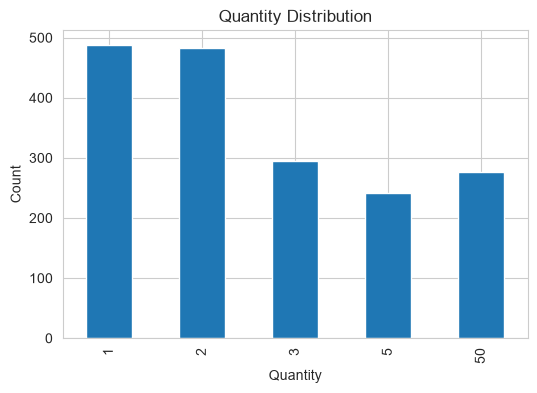

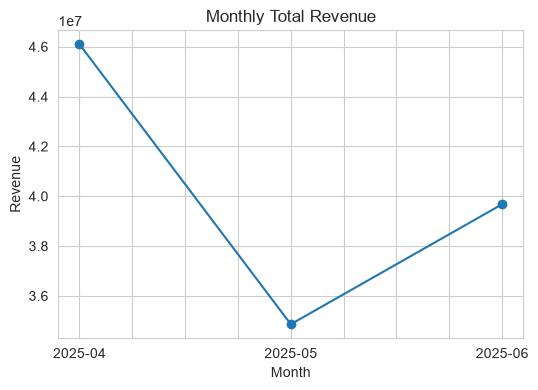

month
2025-04    46099000.0
2025-05    34862500.0
2025-06    39679000.0
Name: revenue, dtype: float64


In [40]:
import matplotlib.pyplot as plt

# ===== 1) 단일 변수 분포 - quantity 히스토그램 =====
plt.figure(figsize=(6,4))
bakery_clean["quantity"].value_counts().sort_index().plot(kind="bar")
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.savefig("d009_outputs/quantity_distribution.png", bbox_inches="tight")
plt.show()

# ===== 2) 시간 흐름 분석 - 월별 매출 추이 =====
monthly_total = bakery_clean.groupby("month")["revenue"].sum()

plt.figure(figsize=(6,4))
monthly_total.plot(kind="line", marker="o")
plt.title("Monthly Total Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.savefig("d009_outputs/monthly_revenue.png", bbox_inches="tight")
plt.show()

print(monthly_total)

In [36]:
n_50_revenue = bakery_clean.loc[bakery_clean["quantity"] == 50, "revenue"].sum()
total_revenue = bakery_clean["revenue"].sum()
print(f"{n_50_revenue/total_revenue:.1%}")

80.4%


In [37]:
# 월별로 매출 1위 매장이 바뀌는지 확인
for month in store_month.columns:
    top_store = store_month[month].idxmax()
    print(f"{month} 매출 1위 매장: {top_store} ({store_month[month].max():,.0f}원)")

2025-04 매출 1위 매장: S06 (9,156,000원)
2025-05 매출 1위 매장: S01 (7,243,500원)
2025-06 매출 1위 매장: S02 (7,996,500원)


# 빵셀러 데이터 정제·집계 보고서

## 1. 데이터 개요
- 출처: (가상) 빵셀러 베이커리 체인 운영 로그
- 기간: 2025-04-01 ~ 2025-06-30 (3개월)
- 원본 행 수 / 정제 후 행 수: ( 2164 )행 → ( 1784 )행

- 한 행이 의미하는 관측 단위: 특정 매장·날짜·시간대에 판매된 상품 1건

- 주요 컬럼의 의미:
  - store_id: 매장 코드
  - date_str: 판매 날짜
  - item: 판매 상품명
  - quantity: 판매 수량
  - unit_price: 상품 단가
  - revenue: 매출(quantity x unit_price)
- 분석에서 특히 중요하게 볼 컬럼: revenue(매출 KPI 핵심), date_str(월별 트렌드), store_id(매장별 비교)

## 2. 발견한 품질 문제
- 결측: (revenue 컬럼  2.77%)
- 중복: ( 321 건)
- 이상치: ( quantity : 50 )
- 표기 혼재: (date_str 칼럼 날짜 표기방식 차이로 혼재, item 칼럼 케익과 케이크 표기 혼재)

## 3. 처리 결정과 근거 (5줄로)
1. 중복 행 ( 321 )건 → 완전 동일 행은 시스템 오류로 간주, 제거
2. store_id 공백 (10건) →  앞뒤 공백 제거로 매장 코드 표준화
3. item '케익' → '케이크' (8건) →  표기 통일로 그룹 집계 오류 방지
4. revenue 음수 → 별도 보관 ( 1 )건 → 환불로 판단, refunds_bakery로 별도 보관
5. revenue 결측 ( 60 )건 → 계산 근거 없어 제거 (이유: 원인 불명, 추정 대체 시 KPI 왜곡 우려)

## 4. EDA 결과

**단일 변수 분포**
![Quantity Distribution](d009_outputs/quantity_distribution.png)
quantity는 1, 2, 3, 5, 50 다섯 가지 값으로 구성되어 있으며, 
이 중 50은 전체 건수의 약 14%지만 매출 기준으로는 전체 매출의 약 80.4%를 차지함.

**시간 흐름 분석**
![Monthly Revenue](d009_outputs/monthly_revenue.png)
월별 전체 매출을 비교한 결과, 4월(약 4,600만원)에서 5월(약 3,600만원)로 감소했다가 
6월(약 4,000만원)에 다시 소폭 회복함. 다만 데이터가 3개월치뿐이므로 계절성이라고 단정하기는 어려움.

**핵심 KPI**
- 월별·매장별 매출(store_month), 상품별 평균단가·총매출(item_kpi) 참고.

**발견한 인사이트**
1. quantity=50 값은 건수 기준으로는 14%에 불과하지만, 매출 기준으로는 전체의 80.4%를 차지함
   → 소수의 대량 주문이 전체 매출을 견인하는 구조로 판단됨. 
   단순 이상치로 삭제하면 실제 매출 대부분을 놓치게 되어 삭제하지 않고 유지함.

2. 월별 매출 1위 매장이 4월(S06) → 5월(S01) → 6월(S02)로 매월 바뀜
   → 특정 매장이 꾸준히 1위를 유지하지 못하고, 매장별 매출 순위가 매월 크게 변동함.

3. kpi 결과
 (월·매장 관점) 가장 매출이 큰 매장과 그 월: 2025-04월의 S06매장 
 (상품 관점) 매출 1위 상품: 쿠키

## 5. 한계와 후속 작업
1. 분석 기간이 3개월(90일)로 짧아 계절성·연간 트렌드 파악이 어려움
2. revenue 결측 60건을 원인 분석 없이 제거해, 실제보다 매출 KPI가 낮게 잡혔을 가능성이 있음
3. quantity=50이 매출의 80%를 차지해 삭제하지 않았으나, 실제 대량 주문인지 입력 오류인지는 
   이 데이터만으로 단정할 수 없음
4. 환불(refunds_bakery)을 분리만 하고 원인별 분석은 하지 않아, 어떤 상품·매장에서 환불이 
   잦은지는 확인하지 못함 → 환불 사유 컬럼이 추가되면 확인 가능
5. item 표기 통일을 '케익→케이크' 한 가지만 처리해, 다른 오타·변형 표기가 남아있을 가능성이 있음


| 단계 | 액션 | 근거 | 결과 |
|---|---|---|---|
| 1. 중복 제거 | 완전 중복 행 drop | 동일 키 동일 값은 시스템 입력 오류로 간주 | 321건 제거 |
| 2. 문자열 정제 | store_id를 'strip' & item '케익' -> '케이크'로 통일 | 문자열 공백 제거 및 표기 혼재 통일 | store_id 공백 (10건), item 케익 (8건) 통일 |
| 3. 날짜 파싱 | date_str을 datetime으로 | 월별 집계가 분석 목적이므로 datetime 필요 | NaT(파싱 실패): 0건 |
| 4. 이상치 처리 | 음수 revenue 분리, 수량 상위 1% 컷오프 | 매출 분석이 목적이므로 환불은 별도 보관 | 환불 1건, 수량 상위 컷오프 [50] |
| 5. 결측치 처리 | revenue 결측 행 제거 | 결측은 결제 실패 로그로 추정(MCAR 가정), 매출 왜곡 방지 | 최종 60건 내외 제거 |